# Preparation

In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

lr_list = np.array([1e-02, 1e-03, 1e-04, 1e-05, 1e-06, 1e-07, 1e-08])

lr_num = len(lr_list)
avg_reward_benchmark=np.zeros(lr_num)
avg_reward_plot_mi=np.zeros(lr_num)
avg_reward_plot_mc=np.zeros(lr_num)
avg_reward_plot_mmc=np.zeros(lr_num)

def calculate_average_reward(episode_rewards):
    """
    Compute the cumulative average reward per step for each episode.
    """
    cumsum_rewards = np.cumsum(episode_rewards, axis=1)
    step_counts = np.arange(1, episode_rewards.shape[1] + 1)
    average_rewards = cumsum_rewards / step_counts
    return average_rewards


def load_dir(dirs):
    """
    Load all .npy files from a directory and compute statistics.
    Returns a list of tuples containing global average, label, and mean curve.
    """
    data_list = []  
    cache_data = [] 
    if not os.path.exists(dirs):
        return data_list, cache_data
    for file_name in os.listdir(dirs):
        if not file_name.endswith('.npy'):
            continue
        pure_name = os.path.splitext(file_name)[0]
        split_list = pure_name.split("_")
        label = "_".join(split_list[5:6])        
        file_full_path = os.path.join(dirs, file_name)        
        data = np.load(file_full_path)
        avg_data = calculate_average_reward(data)
        global_avg = np.mean(avg_data)
        mean_curve = np.mean(avg_data, axis=0) if avg_data.ndim > 0 else avg_data
        std_curve = np.std(avg_data, axis=0) if avg_data.ndim > 0 else 0
        data_list.append((global_avg, label, mean_curve))
        cache_data.append((label, mean_curve, global_avg, std_curve))
    return data_list, cache_data

def plot_benchmark(envs,lr):
    dir = f"{envs}/{lr}/benchmark"
    _, data = load_dir(dir)
    avg = np.array([d[1] for d in data])
    std = np.array([d[3] for d in data])   
    mean_line = np.mean(avg, axis=0)
    mean_std = np.mean(std, axis=0)        
    plt.plot(range(10000), mean_line, color='gray', linestyle='--', linewidth=1.5,
             label=f'Benchmark')
    plt.fill_between(range(10000), mean_line - mean_std, mean_line + mean_std,
                     color='gray', alpha=0.2) 
    plt.xlabel("Training Steps")
    plt.ylabel("Average Reward")

def plot_mi(envs,lr):
    dir = f"{envs}/{lr}/Meta"
    _, data = load_dir(dir)
    avg = np.array([d[1] for d in data])
    std = np.array([d[3] for d in data])
    mean_line = np.mean(avg, axis=0)
    mean_std = np.mean(std, axis=0)
    plt.plot(range(10000), mean_line, color='#2ca02c', linestyle=':', linewidth=1.5,
             label=f'MI')
    plt.fill_between(range(10000), mean_line - mean_std, mean_line + mean_std,
                     color='#2ca02c', alpha=0.2)
    plt.xlabel("Training Steps", fontsize=16)
    plt.ylabel("Average Reward")

def plot_mc(envs,lr):
    dir = f"{envs}/{lr}/MC"
    _, data = load_dir(dir)
    avg = np.array([d[1] for d in data])
    std = np.array([d[3] for d in data])
    mean_line = np.mean(avg, axis=0)
    mean_std = np.mean(std, axis=0)
    plt.plot(range(10000), mean_line, color='#ff7f0e', linestyle='-.', linewidth=1.5,
             label=f'MC')
    plt.fill_between(range(10000), mean_line - mean_std, mean_line + mean_std,
                     color='#ff7f0e', alpha=0.2)
    plt.xlabel("Training Steps", fontsize=16)
    plt.ylabel("Average Reward", fontsize=16)

def plot_mmc(envs,lr):
    mmc_dir = f"{envs}/{lr}/MMC"
    _, mmc_data = load_dir(mmc_dir)
    avg_mmc = np.array([d[1] for d in mmc_data])
    std_mmc = np.array([d[3] for d in mmc_data])
    mean_line = np.mean(avg_mmc, axis=0)
    mean_std = np.mean(std_mmc, axis=0)
    plt.plot(range(10000), mean_line, color='#1f77b4', linestyle='-', linewidth=2.0,
             label=f'M$^2$DDPG (Proposed)')
    plt.fill_between(range(10000), mean_line - mean_std, mean_line + mean_std,
                     color='#1f77b4', alpha=0.2)
    plt.xlabel("Training Steps", fontsize=14)
    plt.ylabel("Average Reward", fontsize=14)

def plot_avg(alg,envs,lr):
    dir = f"{envs}/{lr}/{alg}"
    _, data = load_dir(dir)
    avg = np.array([d[1] for d in data])
    return avg

def highlight_max(lr_array, reward_array, color, marker, offset=(0, 12), zorder=5):
    max_idx = np.argmax(reward_array)
    max_lr = lr_array[max_idx]
    max_val = reward_array[max_idx]
    
    plt.scatter([max_lr], [max_val], color=color, marker=marker, 
                s=200, edgecolors='black', linewidths=1.5, zorder=zorder)
    
    plt.annotate(f'{max_val:.2f}', 
                 xy=(max_lr, max_val), 
                 xytext=offset, 
                 textcoords='offset points',
                 ha='center', fontsize=10, color=color, fontweight='bold')


# Fig. 3(a) $N=4$

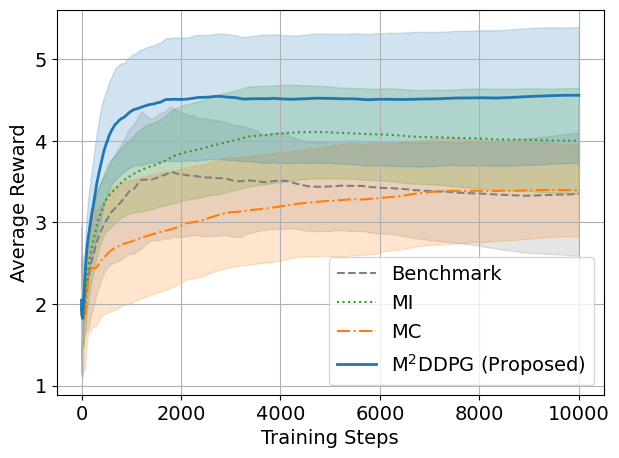

In [5]:
fig = plt.figure(figsize=(24, 5))
plt.subplot(1,3,1)

envs = "4_4_4"
plot_benchmark(envs, 1e-03)
plot_mi(envs, 1e-04)
plot_mc(envs, 1e-04)
plot_mmc(envs, 1e-03)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 
plt.legend(loc='lower right', fontsize=14)
plt.grid(True)

plt.show()

# Fig. 3(b) $N=10$

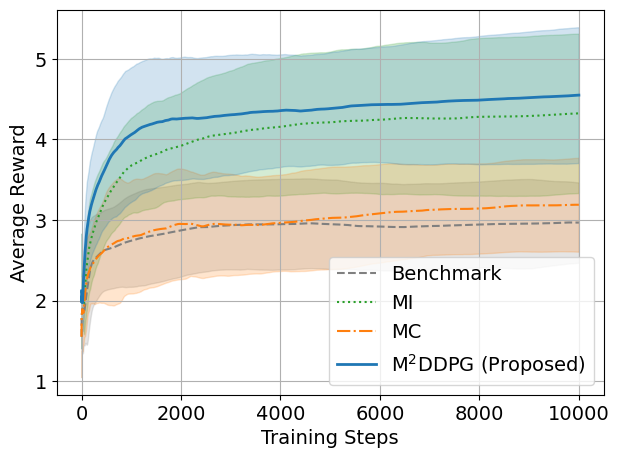

In [6]:
fig = plt.figure(figsize=(24, 5))
plt.subplot(1,3,1)

envs = "4_10_4"
plot_benchmark(envs, 1e-04)
plot_mi(envs, 1e-04)
plot_mc(envs, 1e-04)
plot_mmc(envs, 1e-08)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 
plt.legend(loc='lower right', fontsize=14)
plt.grid(True)

plt.show()

# Fig. 3(c) $N=20$

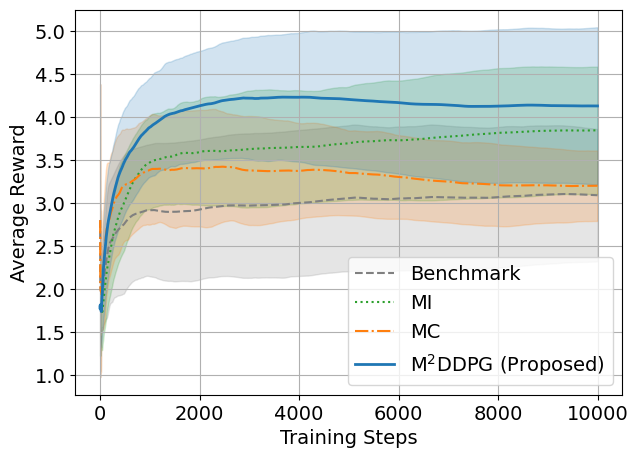

In [7]:
fig = plt.figure(figsize=(24, 5))
plt.subplot(1,3,1)

envs = "4_20_4"
plot_benchmark(envs, 1e-04)
plot_mi(envs, 1e-04)
plot_mc(envs, 1e-04)
plot_mmc(envs, 1e-08)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 
plt.legend(loc='lower right', fontsize=14)
plt.grid(True)

plt.show()

# Table II

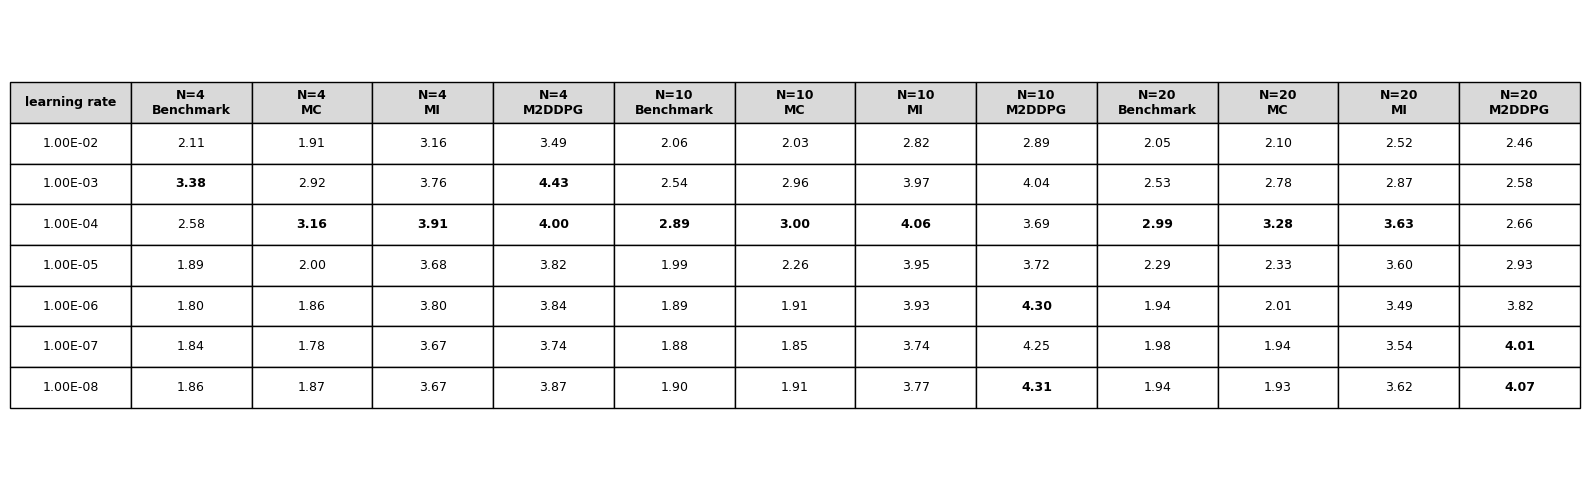

In [ ]:
def get_metric(env, lr, method):
    """
    Retrieve the mean global average reward for a given environment,
    learning rate, and method.
    """
    dir_map = {
        'Benchmark': 'benchmark',
        'MC': 'MC',
        'MI': 'Meta',
        'M2DDPG': 'MMC'
    }
    dir = f"{env}/{lr}/{dir_map[method]}"
    _, data = load_dir(dir)
    if len(data) == 0:
        return np.nan
    return np.mean([d[2] for d in data])

# Experiment configurations
envs = ["4_4_4", "4_10_4", "4_20_4"]
env_labels = ["N=4", "N=10", "N=20"]
methods = ['Benchmark', 'MC', 'MI', 'M2DDPG']

num_rows = len(lr_list)
num_cols = len(envs) * len(methods)
data_matrix = np.full((num_rows, num_cols), np.nan)

# Populate the data matrix by iterating over learning rates, environments, and methods
for i, lr in enumerate(lr_list):
    col_idx = 0
    for env in envs:
        for method in methods:
            data_matrix[i, col_idx] = get_metric(env, lr, method)
            col_idx += 1

# Identify the maximum and second maximum values for each column
max_indices = []
second_max_indices = []
for j in range(num_cols):
    col = data_matrix[:, j]
    if np.all(np.isnan(col)):
        max_indices.append(-1)
        second_max_indices.append(-1)
    else:
        valid_mask = ~np.isnan(col)
        valid_values = col[valid_mask]
        valid_indices = np.where(valid_mask)[0]
        if len(valid_values) >= 2:
            # Sort in descending order to get top 2
            sorted_order = np.argsort(valid_values)[::-1]
            max_indices.append(valid_indices[sorted_order[0]])
            second_max_indices.append(valid_indices[sorted_order[1]])
        elif len(valid_values) == 1:
            max_indices.append(valid_indices[0])
            second_max_indices.append(-1)
        else:
            max_indices.append(-1)
            second_max_indices.append(-1)

# Prepare cell text for the table
cell_text = []
for i, lr in enumerate(lr_list):
    row = [f"{lr:.2E}"]
    for j in range(num_cols):
        val = data_matrix[i, j]
        row.append(f"{val:.2f}" if not np.isnan(val) else "-")
    cell_text.append(row)

# Build column labels with multi-level headers
col_labels = ['learning rate']
for env_label in env_labels:
    for method in methods:
        col_labels.append(f"{env_label}\n{method}")

# Create the figure and hide axes
fig, ax = plt.subplots(figsize=(16, 5))
ax.axis('off')

# Render the table
table = ax.table(
    cellText=cell_text, 
    colLabels=col_labels, 
    loc='center', 
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style the header row: gray background and bold text
for i in range(len(col_labels)):
    cell = table[(0, i)]
    cell.set_facecolor('#D9D9D9')
    cell.set_text_props(weight='bold')

# Indices of M2DDPG columns in the data matrix (method index 3 out of 4 per environment)
m2ddpg_col_indices = [3, 7, 11]

# Style data cells: bold the maximum in every column,
# and also bold the second maximum in the three M2DDPG columns
for i in range(1, num_rows + 1):
    for j in range(len(col_labels)):
        cell = table[(i, j)]
        cell.set_fontsize(9)
        if j == 0:
            continue
        data_col_idx = j - 1
        row_idx = i - 1
        # Bold the maximum value for all columns
        if max_indices[data_col_idx] == row_idx:
            cell.set_text_props(weight='bold')
        # Bold the second maximum value specifically for M2DDPG columns
        if data_col_idx in m2ddpg_col_indices and second_max_indices[data_col_idx] == row_idx:
            cell.set_text_props(weight='bold')

plt.tight_layout()
plt.show()

# Fig. 4(a)  $N=4$

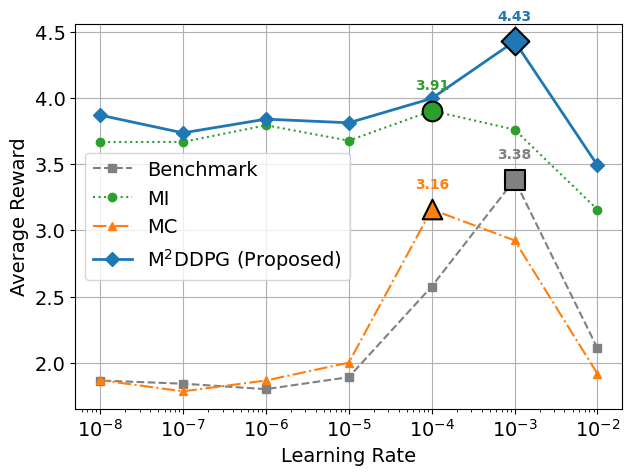

In [9]:
fig = plt.figure(figsize=(24, 5))

plt.subplot(1,3,1)
envs = "4_4_4"

for i, lr in enumerate(lr_list):
    avg_reward_benchmark[i] = np.mean(plot_avg("benchmark", envs, lr))
    avg_reward_plot_mi[i] = np.mean(plot_avg("Meta", envs, lr))
    avg_reward_plot_mc[i] = np.mean(plot_avg("MC", envs, lr))
    avg_reward_plot_mmc[i] = np.mean(plot_avg("MMC", envs, lr))

plt.plot(lr_list, avg_reward_benchmark, color='gray', marker='s', linestyle='--', 
         markersize=6, linewidth=1.5, label='Benchmark', zorder=2)
plt.plot(lr_list, avg_reward_plot_mi, color='#2ca02c', marker='o', linestyle=':', 
         markersize=6, linewidth=1.5, label='MI', zorder=2)
plt.plot(lr_list, avg_reward_plot_mc, color='#ff7f0e', marker='^', linestyle='-.', 
         markersize=6, linewidth=1.5, label='MC', zorder=2)
plt.plot(lr_list, avg_reward_plot_mmc, color='#1f77b4', marker='D', linestyle='-', 
         markersize=7, linewidth=2.0, label='M$^2$DDPG (Proposed)', zorder=2)

highlight_max(lr_list, avg_reward_benchmark, color='gray', marker='s', offset=(0, 15))
highlight_max(lr_list, avg_reward_plot_mi, color='#2ca02c', marker='o', offset=(0, 15))
highlight_max(lr_list, avg_reward_plot_mc, color='#ff7f0e', marker='^', offset=(0, 15))
highlight_max(lr_list, avg_reward_plot_mmc, color='#1f77b4', marker='D', offset=(0, 15))

plt.xscale('log')
plt.xticks([1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2], ['$10^{-8}$', '$10^{-7}$', '$10^{-6}$', '$10^{-5}$', '$10^{-4}$', '$10^{-3}$', '$10^{-2}$'])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 
plt.legend(fontsize=14)
plt.xlabel("Learning Rate", fontsize=14)
plt.ylabel("Average Reward", fontsize=14)
plt.grid(True)

plt.show()

# Fig. 4(b)  $N=10$

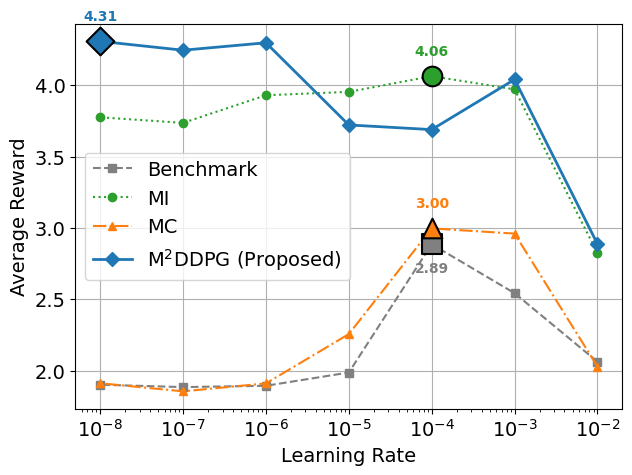

In [16]:
fig = plt.figure(figsize=(24, 5))

plt.subplot(1,3,1)
envs = "4_10_4"

for i, lr in enumerate(lr_list):
    avg_reward_benchmark[i] = np.mean(plot_avg("benchmark", envs, lr))
    avg_reward_plot_mi[i] = np.mean(plot_avg("Meta", envs, lr))
    avg_reward_plot_mc[i] = np.mean(plot_avg("MC", envs, lr))
    avg_reward_plot_mmc[i] = np.mean(plot_avg("MMC", envs, lr))

plt.plot(lr_list, avg_reward_benchmark, color='gray', marker='s', linestyle='--', 
         markersize=6, linewidth=1.5, label='Benchmark', zorder=2)
plt.plot(lr_list, avg_reward_plot_mi, color='#2ca02c', marker='o', linestyle=':', 
         markersize=6, linewidth=1.5, label='MI', zorder=2)
plt.plot(lr_list, avg_reward_plot_mc, color='#ff7f0e', marker='^', linestyle='-.', 
         markersize=6, linewidth=1.5, label='MC', zorder=2)
plt.plot(lr_list, avg_reward_plot_mmc, color='#1f77b4', marker='D', linestyle='-', 
         markersize=7, linewidth=2.0, label='M$^2$DDPG (Proposed)', zorder=2)

highlight_max(lr_list, avg_reward_benchmark, color='gray', marker='s', offset=(0, -20))
highlight_max(lr_list, avg_reward_plot_mi, color='#2ca02c', marker='o', offset=(0, 15))
highlight_max(lr_list, avg_reward_plot_mc, color='#ff7f0e', marker='^', offset=(0, 15))
highlight_max(lr_list, avg_reward_plot_mmc, color='#1f77b4', marker='D', offset=(0, 15))

plt.xscale('log')
plt.xticks([1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2], ['$10^{-8}$', '$10^{-7}$', '$10^{-6}$', '$10^{-5}$', '$10^{-4}$', '$10^{-3}$', '$10^{-2}$'])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 
plt.legend(fontsize=14)
plt.xlabel("Learning Rate", fontsize=14)
plt.ylabel("Average Reward", fontsize=14)
plt.grid(True)

plt.show()

# Fig. 4(c)  $N=20$

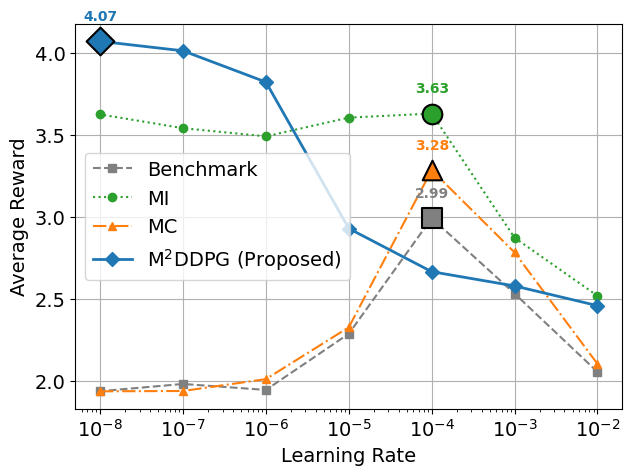

In [13]:
fig = plt.figure(figsize=(24, 5))

plt.subplot(1,3,1)
envs = "4_20_4"

for i, lr in enumerate(lr_list):
    avg_reward_benchmark[i] = np.mean(plot_avg("benchmark", envs, lr))
    avg_reward_plot_mi[i] = np.mean(plot_avg("Meta", envs, lr))
    avg_reward_plot_mc[i] = np.mean(plot_avg("MC", envs, lr))
    avg_reward_plot_mmc[i] = np.mean(plot_avg("MMC", envs, lr))

plt.plot(lr_list, avg_reward_benchmark, color='gray', marker='s', linestyle='--', 
         markersize=6, linewidth=1.5, label='Benchmark', zorder=2)
plt.plot(lr_list, avg_reward_plot_mi, color='#2ca02c', marker='o', linestyle=':', 
         markersize=6, linewidth=1.5, label='MI', zorder=2)
plt.plot(lr_list, avg_reward_plot_mc, color='#ff7f0e', marker='^', linestyle='-.', 
         markersize=6, linewidth=1.5, label='MC', zorder=2)
plt.plot(lr_list, avg_reward_plot_mmc, color='#1f77b4', marker='D', linestyle='-', 
         markersize=7, linewidth=2.0, label='M$^2$DDPG (Proposed)', zorder=2)

highlight_max(lr_list, avg_reward_benchmark, color='gray', marker='s', offset=(0, 15))
highlight_max(lr_list, avg_reward_plot_mi, color='#2ca02c', marker='o', offset=(0, 15))
highlight_max(lr_list, avg_reward_plot_mc, color='#ff7f0e', marker='^', offset=(0, 15))
highlight_max(lr_list, avg_reward_plot_mmc, color='#1f77b4', marker='D', offset=(0, 15))

plt.xscale('log')
plt.xticks([1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2], ['$10^{-8}$', '$10^{-7}$', '$10^{-6}$', '$10^{-5}$', '$10^{-4}$', '$10^{-3}$', '$10^{-2}$'])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 
plt.legend(fontsize=14)
plt.xlabel("Learning Rate", fontsize=14)
plt.ylabel("Average Reward", fontsize=14)
plt.grid(True)

plt.show()